<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #8b5cf6; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Máquinas de Soporte Vectorial: Margen Máximo y Margen Blando 🛡️📐
      </h1>
      <p style="margin: 6px 0 0 0; color: #8b5cf6; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Linear SVM & Soft Margin
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #8b5cf6; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/00_Maquinas_de_Soporte_Vectorial_Lineal_y_Margen_Blando.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Introducción: La Idea Central de una Máquina de Soporte Vectorial 🛡️

Los módulos anteriores construyeron clasificadores basados en particiones del espacio (árboles) o en la cercanía a vecinos (KNN, revisado en el Módulo 03). Una **Máquina de Soporte Vectorial** (*Support Vector Machine*, SVM) ataca el problema de clasificación desde un ángulo geométrico distinto: en lugar de preguntar "¿a qué vecinos se parece este punto?" o "¿qué regla divide mejor la impureza?", pregunta **¿cuál es la frontera de decisión que deja el mayor colchón de seguridad posible entre las dos clases?**

**La intuición del margen máximo:** dado un conjunto de puntos separables en dos clases, existen en general **infinitos** hiperplanos (líneas, en 2D) que los separan perfectamente. De todos ellos, SVM elige uno en particular: el que **maximiza la distancia mínima** entre el hiperplano y el punto más cercano de cada clase. Esa distancia se llama **margen**, y los puntos que quedan exactamente sobre el borde del margen —los que "sostienen" la frontera— se llaman **vectores de soporte**. Son los únicos puntos que determinan dónde queda la frontera: mover cualquier otro punto del conjunto de entrenamiento, siempre que no cruce el margen, no cambia el modelo en absoluto.

| Concepto | Definición geométrica | Rol en el modelo |
|---|---|---|
| **Hiperplano separador** | $w^T x + b = 0$ | La frontera de decisión misma |
| **Margen** | Distancia mínima entre el hiperplano y los puntos de entrenamiento más cercanos de cada clase | Lo que SVM maximiza |
| **Vectores de soporte** | Puntos de entrenamiento que caen exactamente sobre el borde del margen (o dentro de él, en el caso blando) | Los únicos puntos que definen $w$ y $b$ |
| **¿Por qué maximizar el margen?** | Un margen amplio deja más "espacio de maniobra" antes de que un punto nuevo, ligeramente distinto a los de entrenamiento, cruce al lado equivocado | Mejor capacidad de generalización, no solo de ajuste |

Este cuaderno cubre el caso **lineal**: la frontera de decisión es un hiperplano recto. El cuaderno 01 de este mismo módulo extiende la idea a fronteras curvas mediante el **truco del kernel**.

---
## 2. Los Datos: Segmentación de Clientes 📋

Para ilustrar el margen máximo con un caso real (no un dataset de juguete artificialmente separable), se usa `clientes_segmentacion_compleja.csv`: 1500 clientes descritos por variables demográficas y de comportamiento (`edad`, `ingresos_mensuales`, `gastos_mensuales`, `score_digital`, `llamadas_soporte`, `antiguedad_meses`), con una variable objetivo `segmento` de **3 clases** (0 = Básico, 1 = Estándar, 2 = Premium, etiquetas asumidas por orden de valor promedio de ingreso).

In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_segmentacion_compleja.csv": "...",
    "diagnostico_celular.csv": "H4sIAChomWoC/219244tO27k+wD+k0JBoqjb1xgNuzHwg91Guz2Yzx8yIqi1tjEPveuc0zsrMyWKDAaDzL//5V//7W///O9/jT9//vHX//uP//77X/Bvf/n5z7/+/d/+/a//+Hv9v3/5+1/r//qv//7L//m3f/3Lv+pf/+Vv//6ff/mXP/7Df/zLH3/jP//7P/7xt//6Z/73+Af8xv/6if/rf//H3/7rH//2L3/7p//V9++9P739jvPTzX7jz9b6b/tpv70fjx+294ofI/5z/kff8eOf/pe137l/4uodfw77vfnnwnXt+M4L2z4LP8+6+NfWd17a72/8B+u/NuOi+D/ixm3wlu3mvfq8eUW/+D3d9sV1/dftx/Coe//O8zPO+uVDxa+KJz0jLzPvuKxN05NaPJ3/Do/bzbig2926XRv5Y9jB7fBn84G72a/H883f/XMs39Xjnp2Pg7+38aD453ba4SMevNT9jV/V8z1jNb1xVa6vwVfE2trGmjguG7+xqvGgZ/zceNyfGffiXzv4sXziV4yVy9PmPVPXtVzIYz8nFuRnxi0PHxG3usPyx5mXV8/3ZuvH/Lf5zxm/N19t1u3y99vALhh/SztTKxLbG+s/YoHjtSwWZsc68v2t4cHW4lYPu/w5jJfGMp60lpO2NmJd9ulals1FvYZ/u9P5i/IXwlZioeNZD6wsbtxt1IWwTp/5BHH/iRfoR/eLFYq/eSfuF4968oFhnLTj1nTDgTeYY72tGD9xEFb/ufmgscO/WMw+Ohbl5r9ZN228cSf8Nx7cdv55V/6KNQ/3osMow6TxgGvwLNTt/Hed3PkeO++/8UrrxK/Ck51FEzFegOvDpufVZsQlceHKE3vCMvetG24siGHvN380O1rO0/Pt+uforbLPM7gwsMw45zQav0frEq+Wp2ilrYUBzbWwMLER/KsnNlFGgD302OOfTis9OEn958zfOAXTms7fnjRX/P25sKaj47L7O8NA01hjUVqe3rBHmmkzGonTaOxOWJ+18FQduz/wrLZgqPNnN/+lT9jcvQF/0fbmC0wYW5ykvtJq8r5jxznsHhfq9NJHaFnjGnq2YdqNsL+4Pr1oz5e7ceHiQaeHmvQXxr2VJwyPErdasOt0nrfTSusg2uYPLGyH5dLWTt4sjnMcQO8/y51b33B64uLz8Yrt7DPknBa8TLqotIFYnPtej8sD/9KdNrpH12EKS5sRCLCa/rNxEvOvHyzGwmL0degu9ux6uYwQM2w23m7m280JDxqm5nzLyfU/MIO273wPijumIfDst3NkMYtveGDko2NhzF0BIiJWXL0zPsQ59fC93AQ63dnxb9Z55PsxPSj9Gpx2hsBzr84838zpD50+39rQWYoViZgX7xIWnBGwL6vlpJPZfL7F99zzjs/ZTW+Yb5ah6LS0NgQfPCccdhgpw+ieZWThH3LfL4wsTtO68hULtxsD7zcc77eanKHnjsd14UnSpYVvGuVDjykmwWC4nC1uX2c+XjXWM8LugUecsUr0e5ebPTYjks2loxi/sOOeEQHSaGLX03MseaeIQti6WH24mxbBBv/dzr26qcMjZlCLW//E02httHtz0hDwABGb3mVcnNi+WN8T/kkveTqfbTXeMf0LvIXMu2WUyLMbfqLHNo74kzGJnpDmEluD3ZgIcdj+xsiURpoxIvakTlPcE24GcCS2mJFmdT2p4QXjz/Ck4UCmz9p9+gpsY52Stvqs7chY2POO4UdjU+bo2v8tyMMrjjHih7exOlAzDS78oWU0jEdaBbhoofA3BbhawytGVAnDD7OLUzU7IUr/pa8XDnFsQjwg9jD+Qzxhr0fN26581NjhOcofTiKUoSVejG4uZJLOwtNGI+zGYXDXSdTe3UaXv6Zc/w5fxRvGP4RTG7n7Nyx1CV8cnJ64xaKdOdxTQpP0FXAa4WRjVQOTeB4Rt13vOBiXLm28jnGAjKl7LnjvePjYyPDzMyzn8GZn0uS4EQHBeOnW8YhlhKeKQLYRGH1srE/sHc7ye87YEzx/nGq+aVxkdHI9sXDiG4Hn7nT7uHffmza15MMR98PRRciIRd9wdFhRBs9Nm02b4ckeo5zq5P3ieIx8V29XZj4Zh6cTKI5Gw7VEyJ0esuelGQfCFyAOmOwOdwn0sQnAGTruLVSUxgZPl+5jBppaQqiDFxDuEYwl8hjlsAC/w1jKYdGxBlBb9FcA1K21RQOKI7dgshkc0///BpiZSBbMConJhOKX0egatyg88+WeIB2Ip45jsDyfd/Rez+u6PXezIadqCZVw03S1sY15QjxPi1kXhHctCf0c/gjjn1fuNV06cFzAzXAFkSEQOTQEb2vtfIBOmDIja6LpsJhw4oHf0q0m+lOwB05R9EaKQbfcuZUGnDrSFeTK3h+/V1ZHRGRwsl24eJ09aidxXWxsYpWftQpO0zwJM2UHYYx2+ZxOPBVhdOVfjge9whyuoEibs67jAbAIc43NT+fsPziNIyAO34xAPA5WowPYAAVhrYNwM+8dPnIEPj1pBTbb7/xGRT3vOPBnJIl7amHS2Fe6n0hpwjonEOcHUIfZ0AbG4smyTIt5ki9CVj6wZa7RicmxEE1Ilz+O8FGnXz6JHDzdjx7VK/IA64VZ8NZn0eztxCp1QB3LmJUnOm3o51otK9MwXq2zsa9XTkT8fjM79VwfrmkECkZIPp7O1myKkIY3W3m3HZYXNrNlbVe7to4pT9TJMj3nyuCaCXTmb3mzk1QDL2WWcJzO5+6lrGO8RCWdYq5teOUMBQUg7PavIBkmyp9zLm1HOo+F3CjDczIhFSXhbqz7YrD02hTQC50Wnh4AwTVyUl5mCJPDgePCYHDZahXr4v/Nm2YSHosTy6Z86tJeIhWmzzpc1wiZUybuE05jp0cOtx1ok5baldQOIh6ft8vEhyJWJkYz73xgsl+Z2KHd8PdoTQOZ53WJ42A38esC06YjP/sBcmRUCysUQQP2enxW9p4IOQ+W5T/3TOK5NJ1Bilty6dX9GU7Lp4xfGTAlwJnHuirVZKDYHbcL560gGbFae+hY1DTwTOcS6czCugI3jDxDnnHfSuAdSVVcf+Fdlx+GjjgF3I/rwv9Mb++onLrxUF2kVe2DruTP8hJ6EJmukUPLAwLocfJ8xAb4WvJVDN55a+EILFf4LJ/y/wsbGWcgAmQY8pov4Bhf7wp0KrrL58SFeNgEAp6Bea0iRgj+ns8YMqbIrndl1TtjTibZLc/HtlohIo2xPvGgbT8Vkw2xMS47YDhmYkmivklOo/HnEPSxWPoCdWlqBHURsZQ/KglPYM/r9OQFO2LDVzqPM/CggSXbJPhs4mJoAnzt02fRhEz+R1FN8Ry1jVv50eA2Kqie4tM6yS3PvDO8pE9lEI3bF/fHvYyJtV0Xw7EPvFy4qtiFjHLXFXKErAZj1XOU4ZPHlhNIMI97Aq14hujv1GyLa/B+uZ+jTCfgQtw0jObC6JfbHzgnIkNXpsY8+bwUK/kDT7By4CxnkWrX+VfP7Io7ureTF41TnGnSyOCRPvLCVc7HVsXD8mjgf73WNElmyzWN/faMdIRSisCNzJ0Nvm/fm4t6NnY/1hT8n10hjkhPmCvfSqsYlpsViEuEfdNbLdAqkU6Lr7j0wEd0r12ScXGui+FKqiKQ6qpMYDTGHGa3fS8RTvx9S0xOxzE+iTnCTcVS5C5yWVw5L5eHKeRIaN/LcaSb8/Qc8cvSc4jeVFQ79Bhhw1yda3jUOL/GyJrcDPj+KTyfBD74fmyFm5gWQesOSNyRO1iazQjgKRfKJCfSo6nMnrc8RMdpajsDa/zrytezq8VpoyhZetTBwBc7+UAnOM50HcC6ftqvfPFg/iCYtOQm+ZKi/gAfkqIecd8rnHtwT0REFDV4VvY9soEJiizicQDVWIF4pF/7grmDFyzfPFRtHQL5nXecea/wUnEqbTQ55CmGnGkd/XPuR+HVyGFI5kXUmHk+Dg/y5UbEI3uR6bS+xPa452WBYgEFxi3FI2Spwb5yiGvMIeKRjpbnYEPCBi7ecp0yO164nKwArf5+k/hhQIkC2hSprqSe0Rz+w7T/11W32TiG+dKFOo9VpYgxZm0FDSV0AdlWlXzyZkkGVfJZUGAwAVhKtcfsDFfLCgpE6EuGlVAgaxa7yj5EYl/EbHisxTDAzArwL85U/LnFJHRH+DfS8nE8WHfoVpwsnvMCPaRTbWJyVW5gQeQcZypZJj4yqCaHcEFbhfHQL4anoOHsIRZXzIfVdQeMThh8smSZCJR/3OIeOrNxepIGr96/vHhsbviqNJ6tyBHZpQxuKd/V0rZTcK6l17nMV5K0HkcbaYqmjTZ6jZ5uLtuPf+BrRt4Yt1lbkY448DCR6ENhZLgIBORh2MPRcMdbBAIvnPDMNl1eswBkz4JkuvL0j4Gs8lB+crnA1kr+DqGHnWPCDs7okdRs4pTAMSo6EOWYCQMsFf52UbqAclkkaWk3sV+6Y2M+r6SBR3Ku/s4UAuMdINfbT5rb/jrE7+dWLj/veFgXOTK2g/nKw7o6+FvFRiaeC4Qic1YgufjXA1r4k3sIis1dLJTI0t2KDdpdrqPosiFsRSi+2tV5lL2uyllGOqswgDjIgc/GvSKgVBJbSnPGbEqTdwGWC1OPgxohJ0xx7UN41cUeNZrCEG1n9ah5Vkbd8mccVUk6I5vOhy+ua3irpXCFKk6mV7EX8cvCOASQClHRaz2wshD+mT+2iWz1FSlZ/iFtlXh+f4jTtyw7E+V4xpXLUnmVCqJ+1oetRqbTFRtvrmf8rUgfE1XHfyEqXqpqycQDggnnnIpxGyRrvt/JQBkw/LfC4FAEFzUyRXTVXmSSkTnETH62J21pWtOpFFs0GymWDK+8DBxJnPu4LDyhVxrYmP+xfkQYsb1XRnaB/hOoAlyvo3LHoZ/Q/qfR0nCWFcJFchQI8iIvT2csIEeOTFyXqxQxh8k1xkJ2kAax5eF05tGBIhUSRjq2CBWypRHNi39uQContyNWbXYRKzq1e8q6ZXW2mMkdVAnyysCMKCi1IY7Eaday7sFntk7AkVYKyDmAc+O+oxWqIrNGDYUXd3Rm5Q2o/aZT3C1xwDji9C8Jitj9Lsh4GDn2WYVyp24Z6zIS5R5dOkhrHr9y/zSkkUkgrdVwhsMUwwLiNT1LuqImVfFnFTmSDnrkMbooK1bIc2t6Uog335fFfpbUyQUf1YWmyyEnv3/hzlvWkc7h+oSBKSujK4/35Q33rpPVkFrFDTd+S2QxCpAqHU3zP7n5K/ohIV+ezAX0eH9GQAgu/6wEnrXHOBrM59bUqex5Kkkm7QQCXlqORgmIkrLw4Sq8jeLYOx0BElaUoeZWUF6XJsiCQOee3LVKhpOMxSktQBJX3YvT5cIiH5gVwFaRFsmNZ04WsTV+ta9KWrt9InPkrsx5j+FwGa3bUFyfqD6v8wRDQ+8oUxez1wpbXaQscfSyGvCzlD8kB8j9GFP7QPcab1opXbiAjFgLbmRMFVnupE+cW6dRfGlfygMWWN2D0nNWoM5RgIx/UAX/1COoILWXwK6jLJjHNANDgF1VvppAdaMEgTXeUhvxHcF2RZCL37nO1NkSRNl1MBajzyh5hWUNMf+8eba0If2pPkDj0R1f+rtRNbqMPTdzrIOUZa6p7KqpgmzFABAYDh8lr8lj1SnngcBiqD5j0jlM5rvjo5aAjTfw1rEhO5fgZ2zpHRo5p7ldmYoylnnqYC2kV30iN4+T5Vd0x2ag9PFnUI7zl+fZEyRNcB5WtaArmOmUV7xLIkVsSMfjYVZu2mimBVkskxoP1FA6vvuStaSgChmFzAWKuC9RzUSRrSu+hhGtqld1naVMibJetXjHZVX+47M2CYha1hJN+05OJZ42XLglg6wa+9mM32OTGIs35o07oaOBUUniMYu0htLgLCKYr3hRUA4MxrLAPhLIhNuKR8xY4rl1PQtd7eOf7GDHjZGVwgmiXAj3OkB1OI613kFU0nLFIRQCOfcrAfTEORvMvrfSWKi2eph8Rr5zJCgQQpqos1v+ggBV+Qt6013Jx1EhCE9V/OOQIoCCpdjPjDVhCAk/lUqzJrxqN/QCzbxVVWew6JkO4FACWLVo1clPEcHKsOfp3+h6p0vfcCFu7YmsaBeKA+M0Ke3k6iALSCR5k0rKCGuVuDShHEk0xlTRflZsBjKn94gFVnjN3IZhUgXhQwjUM2CLZIFspoNKDqcS0F93xHoaC2Zd3mctyVGYfWBjDyrSs20a/dmuWk4rpYZ9V8xuJhwsgAd8SJ3eYSbQtB02+IxfNGIGq4WCB5BPqjiZiA0eZVLBjb7VsUZkSEAGJ5/UMvEMZ/Jdf5RWVFTi0fno5EZW8nnJqIyAgTrP+7pC1VJRR/XLscsbMyczFNlSJHe0f/ZdKFduP21J2NFQtTgFjpI5FmQVCI+1I4HFtArMg2ozPB4X8qUszntl81NJLjVvvdP0UJQgviZFgo2P65cXD3yIPVXvkM7q1uIY4s1M9Wcmyl4ajTvPVzadCVb9bFsYcALMZaADlXBnL7abWrcS7zKeb/DRBB1wWGA7cz37EqQvh8WC/NAba/tRVUulTETjng88pXSVUqGTmosjdFTOLGzklL2ktcUB9Yet7xI6lWxUKcux8lVJcaw88uGrYod2l4c8Z8tTHiFJWmrbqpSD7t554pell7M7S53HfMrEOG4KPfqdVQtulAMuRK0NzeL4Lj/tQWJWp2u+OkBH1JqosOYBflXkxqJ+KQGbCOFW5Epyzzgk8ZaR9W2oQuAJCaeWIPlhUB+dWUsWAmCsKZccDqx6X6n8fkRvTO1jsVb/QxF4obOJkJpesWld5TkIqvgzEl9GyKOUHvuZ6b99BA88TxQTDvK6jM6Ef5aMVdaUQQper4ReZ6JqyKVj2jpTmQbC7q5lXF69PR6IBUtdT3S9/GOq0GhdSMcvBcvSDlBL3yU/a2LkhKqJ3g5kb5ChZVJe5WNKNCozGyoIugmMJS2K0hHUnSPLAjRrZZBXIUdBC+oCJisUri7Ug3MXn+CBVZx6SyltIoPplauMn8HjhR1MHq6SB7q38ckg8pF3layQ7XYUZk6qAitlXS782BVQJXiZq2rl+ZiZjOf+XyjKxofoSiZSZCkrXbOXFAjFwJkS8DzVI29P6pH+eDadR4KAgFpTp4MZYGbKLSnZ/e5o81N4jnfc/8MCDJ0Y8WsPxEfTFXSOMl2/ooAm98dckgc1ReSyhtXNVBJrK8Nc6EmXKpGbP321QuQkWWIVE8zFe9otIlBkEjOj2AyVoKyXPBvl/bhdSoLmR/J+GLLUBRKHQ17yUw4yKS0O5Jp+X3RtVfO8UoWqVDJWYWWo+gdynTgYsw2xJYcFOukg6enWWaVhpqAs8WCu08+5f4SP8E9GuFytHSyVWfYCJMUCdeG4FGclxyksJYplsVQSZ8uKYItVG/ADkSKFj88el5LXcA+F6ePliTxjeb2cZM/7Ii1IwXsKenW8Kt3cEhjTPijxy5AMpfaF2sryl1R25dLyKzIH+KPxLqrmkjAY6uU5YOvDPiqJ5Ctf2mAXjR3AfhUfAHFI5r0oevS1yxmQupST7OycMB7peMsn1Mg6PciL4hEkKDhSQEdAk/LXCrkYdiZQVNp7mJ6JbTvi9aUQEFhyV8UMHQ/jglGGHVyrXOIIoBGA+FMVlNiXQg34nzDKucW1XjfVr4ZUabL1UVl9etsJHRuE+75Vb42EVwV9JXU6cL23opKg2u7gvePvjHO1JeTkO0tK4d6lvBagB94xANEDgDYrxh6VLRbrNJn+7Ie36diz4pmbIZ3P1DFRN8lUl46rCiYuCXuZUQFOZKflbxEC4skZpF1SutEKLDMCjfR4cZSmCw5u6ooCyFuVlJfWpirnBwx2bM8BwfzhzbfE8/zBUzZeXTj1iJPETOKm4SLZbon7pfILMyWSWE+tlXjLcyNSrRWJmYotXUKGrUTLq757ySkbNGymOATwOqRIKeEdpTq2aYKjMA9oc4deN36lV3p1h6uCJFnYKi+5bpXbgNCPPUbwo4BjK5nfTycEW7BwOlDEkJNscTiOnGs7X7p2U82s+tAu5D03nXJSl5mBLGGsJh0anbOW9Mxbh+oC8zbA87CC1aoj5a7XMQg1pHTwXt1kcebtsGkRiktrtY8UP1DO1vdRqPXqgDGB7I7AsTvL0JKRGat75i7trumyxSwS/RqpZCnRC/zbYGI1uixvV6k0sQ63nb1r7kJ0fDgWzLqUumewcYL8SoadVR2ZVl0zX4FudjH2Y9Te4dDnVeBy4v+RCG2pb8JUKpXVnFHNSwbJffayZE4YULfaAa/osj2+FTd7tnrDBY3uQLdpFj2nGHaue5ZHiaqsyrT+GqZwz/QDkEBdO08aqISQIfwKbkXAqrgRTzM6a8kZj7u/6AjhYW4393RJEuDlpSC2uck854Eaha8i9zzfiEytLba86knzKjsP79/Xpythq2WtOjVcbX5WGNsk0TCQJBk4yk9dtXUttpcwYH3cTVMrafxndAeNZzwMpiYpk5fzf4E8vc7Ks3+Tc1pDqoB4GaVIZMmSECLu+EAWFNszUiHHHzK7ZD8JzxY93LClUsvEpVZFjxQKObyI3/5nCxVbm0wgoDGvD0fF6LhQo80zLX3PlabIF9+zInn3RyWk3gbCt6QS4m2vMoJTRDtjVhjhlWD8015GhXhC899MmCQrNFNBSdJ5UyHzI0kfiDkLePBCOqWCUhW9uP3xmDShbL+oKv/p1VFsqC/1YkApzMlsWdU3JhbzeCkv55UuMUBkBMRUegyxUQw5rQonPKEBsr7lJSihHlRs56kgwrw3W1z4K9QoOnavHC+VEAvOFQKaEol0kQNk3K5JCrce9YmezfhL2/Nhsw9H8bEk9wyw5jIiJWqJPRLuHPBYULYX+JCsmBniooO4vqpCaK76cgdzflrpSyn453r2W2BSzVSEEGgM94x5s6iaeNAjquYrUx8iaA2McFYiN6Spfm6hVuI4N65sY/NnSyDgn24h6uAiVU8I8Rjl1VR6k7MTbEld9QfugKM9MN/ZVVaKTEeAU8fbBJSUqndJ6CKgRtRKaPYaKbgsotuv8ZbzU8gc4MDiZmFuARTS2tWKxY2chAXZ+nfVw1FNgw5bj3/NawZUzdXFRcCjUKnItFpV/C8eFhllXndkOxEN7KvRsanu56fXplxo/htkFD1lFKMqUgLbQr6qMownv6X+KkLERoNjsidbSSyPIXnX8JsiFqyy2CSxUbJP8U3gs2u//VOZ/RhEV/ntaQUHgUvCkIMq1UeAS/4zfLKpz2iphq+GvEaZUAb7CAvxouPR/LOrMU6XmiDzWPfTIJcHDBxaizftpaZYInhJENtHilcKDuOVO3FaYufCFiyXJjLjGjljC2D3R4c5kkNd0Pw8Haaqy2vfklTzylKogCnqQMt2kZB0qf6kFnBqFKUEWfYZiZDI9/4ctLj47rIgJ93TRIIrgW+3MHojb7ceMemlMjzsqDkEiKM6ZZ7UGGndQnEiX485AZc0LEFGI8e863Cxv6HjVIZ7Tz1kV/Qa6nOkC1AppE+dkURLBro+/Wu8Yd+lh9AJXmVuYu1S7v6yrYmGXE/kNUedrll6COmEIsnnP0DKz64q1GAD+aDXwVVG30WAd/m8sY6u9P3AE1QYHBpwMW9ArLS0t4tbknCCNdJwi0+NA9qP3WqbeuxKPlQ9py4nMkUisFhAe/YOX9KhrM+FKmXl4Q2rRbJPKc+7l652QZMTT3vRMBfBTbLj1c/naCQckVLhqPzDtgqoQY+xmFvudl///8Vsm142AdFhupWN6RXZoCmq8SqNLnZblNG5bVf/oQoW02HJonJFFCWW2P+joOaEibN6uk5VYmYRqUMEldpCE0GOj6i/I2imqH+iAqR2PvXIWZdalf46e0P6H22vCYvZ/dpsv0kgosb3Y4Kb+nqyEdDoD3LQxUar3PzyXtLwxA9Rpa3cNJV5DfQL6oaiGKe0+FOnRPra9XpBjW1kuf2Z+w8r18Uu/a5YrYRlZGmIrqRTtJ6GgN6lCK3Fv5CimFIuCqhuW1+tZCOT1DCeYzCe891+qj0ZknHoflT05wKPCYdZ9AIXkmMZbLJ0NV/fGrxBBIsNJsTn65eWInuK8RPrjHZC8bcgqgf0ChMI6H7pVLYGhwypFazKf85JEMnfX/TCri4u7EpHNVk3aGq0CNMYZXIN23ghr8+SnAuN7HLlqjXFcWZFINXn1YUIQR6K8i0FLqfQAQv3GpgQqYvK+sxO8jr2dXG+w4xdWSU9JZfJaCDRw0aFnF2PQ8x46kizLWxU0keGWQS5WtA2iBXCGPBo4dMOujtnr9aluTVvSKpyEmt2v+hmEnAbKHMIOUkjn0Xfq4PIFU4lY4k6DTpSVCszRR2PLtRuuMsxxxEdkkmo94mqA7TObRRmUrQkUlpw32j0Of+Cdz5TLUzgOFKMAhIgjKIf9SFwP9jS3ilcUz8lVwncn42H3L3IWGmt75pPXQdmTPzfKc3CQI9fyp5u6VAYwjpbGboGIakU0BCIWA0Cuh3QpH1UGZtNN+HN6RX6Jo4xqEjTcyQ9DvX8fsCCxkcjQlMHiOeqzaOQnHOIHHKpV9HZqltJJq0H8Nf/nGQiZZMLfUl2msoyXlDfzrfmzewWtMhLAcJTJpEjNGpSj1pBNC9nDv4McFLJ4gKZn2o5tOjEDr5WZkK0ailVTbKNL6XMBMs589iUUqbaJozP7DLbYUWP2JIEDXhiWC8e/9hXpSQi9akxIftLFpqBJBxJ+OgwbqGgoWkYCtRNxBz9Af3X5k2xKVncXQ9SaPQNPYgXUTLt4T3QQA3kcViYt0L8TQj6SCA+RT4Nq025szZlA/DZkvPSCI72yfgIMV9nIdlVtBenkKhIq0l0J3HeO+boGnoVzOygQy9CzqQSr6dOJMPUq0A3nFYimtQmaGfkUj2xaY4ZaVVlu7wO3VpDEfv1TqT4ZWJZk2IozUR1T6o1PKCERDOzbKeTathpruboDFD5QCqrprKXKpCYeqckHjG6oQQZ5u9nluZOHabSoZCxuP0Lj6KMnPKTCzavfbFyElrcJZFOVVnHFw2IruZ5K22TVHJqCFZXWdkk80+kBBFbdnlzctAjDaTO/oxEkbZ8HIF2Z3thzqZBNcC29rEp3NbELZmOtyqzTgooczZceqKk80SGle5durmuwzL9TXBhH9xGhdZRxRaKlVZCHV+V2ZgrLTYlqIn2oWn0x6+RL0gw+Ecu3ks7u1grSeTf8po4y5WLn/Ut1ZvqifIzaviLS6+bs3gilkyrWvQo+nBpgoYWiSyHNU0qyu0ZGK0Q+/HKtJ9Rc+kBNZvjvBZliNkGLoR8opwleyA6ZSyR5KrgMguysT/FErONjmZaGhzn8AQuEPwd6tpJDlQMLWSFCPWgH2cBqCf6nxr9UYMZ1EkHQauxY4TD1I59zwzonPVXRZPZCgSxIIE9yfzxeDV9bhJ5zsBwevXKlztQ0xdYoGxR6TWOR0NUliYrVOXU1qy3HCiAp9QU1dNxqu4leQ83RgMVMYIK+7HQL5ImMTijcLwOLOYk9NJ9mnrs/ZWFkUalHwFBO3flbNIxL1Ugbc5PA5CajbYu7agk7teexGqEtA9raZJLxlxxKluyvZ2P9DNG1U44Fq9T728idV6/YIqbD1zQBIW4xFdtSYtcmUwvd9DfFKin2j7o+pinvSlHUrMpqa3WeH/0Y6MAH4Fv/IzVFUmAtqxrmAZZ/jVWKcylMAM/En91SLhP+cBLvrYGnRUKbl4l2pZJSunSE5pXA7ZQgdeowfI9DYN4No7WzlkVKoKFsc3PyMFHJNp9apZxJaM6MCRfJtDkUhTsby2cnaLm2dYWdzyT04pk5keB+VQjtuYbvoEzGeV4stQXtVzBpORoknpxkGoOPOpfDgQMwT6cVFE1iNdfJDmDLrVq4RzIgtAeGTaQ83HKOW8K1F5x3zQtIRVShUSAfn85eSoTjLrrqHGf/oWlbavHiWVeqnehgu59V+GcaRRHup25XjvYw4ZQ4y9AmQ84vPTlYa7VvS169bV/D69JaVA52iP0NPCTWtoPkTI1beC+qYrulVvCY6jgzqLr7cQ8+UDsGEgiBRofb8VvLg7+5GjE099vIfOCYb2w0raRBdtnwFAmB4ICSoqHlUKssYv6QN8zIfJWGUBqglFTO9RlYrMcx+wqBECmPafaNincr6qpekvmeO0sR2DwADZlV8PQDUVmXHVGq3T68lFmIQeneGR3ieaT7O3qZqXXkWAiS5m+Pg2KHIwGeVhy3Kon0gEsqWhNNGtfo5RBF1EuWVZDFVwJDBksI9E9NMi3Swvd2fCb12a3V/aY2csI1Hxd5YNiNm5hrLuEWVL8EsjDZhGj9Pj7qHCpsSP9vC68CysN95zVjgPlvbIfSSyOtJ5q5LRXvOJE1YvGz7i1rzIDuQ6fWw2KKtm3WVQ+R93Fpm+UpceuVhOxGHSprhZLu6PYF8L0gxaKZI3aG6VMCzhTmtbS/JRnPRzoCC41pfRdnN+epZkg7by6IldVwTEN29htlJXT2M2uepBma1KDqWkOkTM+UgzU1sUB8/41ymd9S/bBcOq4zDLbsdTevMGuvs7o844GGRHT4bT+FbWW7D3unFm3yNstYZE6fxW0XK2jiQiYdE+c6Ti6DyhdzS0cf7Dks9v5muuJYTWXtMb91JHmR6wagWBWabtUnzmwGAOIc0JyGH6vdl4eLWctM0v3Si7G/dTdc5rTzsMysn1YY0ivpsAd9YlMdfP3rckj2UObGDZfNGLfLnZb3bzK9U0jwdC9xmfl9LkD35w1IWl4KbSiqXcVr0iPMA/J8JGnq4HSklb0jWQohkAVNvNXmuHwAIfoM2x7nFYSMYEx8gMBIPmGvUYdI2HSuLtMnR1Kfk7tXt8y3MmxkA1NHQIDgMsXLQeIeZqmzlbzTldQiuoy1tVVL93Q/ob3/UNHqyRgi/Bxv99Q8KYNHDTlfoSQasZSOCg9neee9if1uFnCXhyWcm5pBGU+EtEewft+VyFeiVNP9nFFdjBaVa40dygSdFP71pahzzcNCLWKe6rjcIyn+Fxf8r2lSWJWoxIbRe55IYbzjXlLYCJ3pdS9Clj9IxTJihvU1GEHzt5sDS+cfxRXUJxlwfSrqLwTux5Ok2y91BP05C5rFU8ZhvXmQeFATw6g6D/VIFPzzozqFjDqHDVb1o7cZ6GM7dnRvf8YQi0XW7HX9quYdnDVGR6U/lbvIQfHdOdMD/1bDTw/ICIwlkFDbHuxRDwlkbRp0no1k/mnlytTdbJvOd2pXNY18ei7aqY1LrGslrx6bMiFcmzeWzMhvx5YUWT5qoFgnOs1OSwzZ0Le13oqqUgNrVIZu9VcT7RHY8QWRsKtXr0V4tLnqfkaksNc9y/JTrq5QFtw7TUQjPMKm7TmVbDCJHvdk1qqlfecWSh7SmN9b+BxoSVwm9UJchH2DMKmgdHJPJPFZHTx6yqaLZWUIaU0DDHusKTU8SmJoffRyG5VOtioTQlEzaJUOlF90ufwSC+12HfBguT/vxJg0loLQrfhmkd5NCTHS6R+pcDovaqPbajs2dELel+to6YCVquzundL1ZThEla3N1TcXj0dGs0kB+9CqKa8ciMu87Yomd3zyUXIizP3EYdHTo/WjmOJXvnDQTvVpKZ1EjhcT/dDK5goyAyv+YezIonmwKnIpWW2a6Xh6xrU1kGe9WRTJY2WipZT/tUq0UmedDB1nJizAWJqKEh2io7PrPckeMRsaw4FjNTQRWIbjkCiwc5+80SznRNFSgo63lzJZDJQC9wboFsVjqGeGjXXKcreN25xjoqV0HrkxH37mut0hdaXTufyOz89K5k/TWT5BrWP1MynJphzPdf6YwQqM16U9Q9mTM9Z/etSwEVglLuSEtRWxZEFqGXQeiQh2mvy/tC4KwnFdhed8RibbMqYaOdI/UFKPa5UCJJ6tJqWUbOQz2cACjBeTV6uIQ0KVVNEyKs77FUBnqJsxPcsB92aSXyPeo6E0qfGbmQ3guqAJxXPKX2Fn7yjBsyeKw3eFz+wnAp5Y5Meqrs9x4XnqN+yoKP23rx8cDQQWSYW19CxAnkHRoSuaj+ur3OY5p5sveP3tMYD5SgIEe+V7qlIOU/py5YEP/vPSeoG9Y2dj/pme30NpkRtQrPn7aXr0yLZQxSu0sv0NIyqel5K1101h+4auFKz29er8M+vkSTtyb1UQFyg7HruYxZo38yMGpsiDqS+LZJTpm7NeEm+Jh8AmuxbpcdLubIxVTRGT7aZclVN0s9MDA7Q6PlyOWxE1bimOauLHM1LB53LKFcmouxy5kv+W60YpCcDfT26Lwuj0MIhGuSA+vs9Z15p89p/dHdjgAEZxuxZy563WtMmBz5dnKRmN5gVH5KhEkTRhuF6jenYq76yc//klpB9ZEQnjuwBQf+YBaAKck76oZ+br7x1IEDYOMWHQ4nFg7h4W00sGBoNtyubwKeZ8pMkmLiwuioMAcoVz4+GQ0tAN8tvXEHeFBpvICwp7ayyXwUqE/R9Ew8c5fzJPqfUwpXUXa2dRWWzRJ55wS1dB6DS5LyORLA1Ho49s4cf+VGedvutLL9zZPMoFmS+JEY88ZFw4Ha5LNuf17x5InNOHztW5OTkWEsIIFdir9XJMT63rfe1iGofYpDrNbFNVejsspFYFEDA35i/J9usr63oszuuz+5Unp51Kg5Pa0nGbX8fJyEgv6KyutoQXsMadE8c65BHY2sm6Z2EKpQ4hBeXu/L1NcsYpymRRxbmSzC8NPRIIGf2+urDLfmAg1vKhiUD+OjrqS8pzXHKL8n01kZScAAibIOITfXA/JpfXyMzXZ1Eoz9Sat2fmraXk95qpNB2NbloZsVYqmiMVkP3OLLf0dDXOe1Zze9XlB89v7JCSSg72hXTm7PPJoBdCYbL2pamL3r1+5Zc9KjFH93oB+Mh2v6jsGXiJfns+w85LLyBhoI8+ZvUza6OwKwclgiy6rgdw3Ay+YHZ5pQwaV00wdCk9j0iXdZnKqmh/zR8ZKb7p6K5tA1HDWzrqLvvzrK9NSU01tcJTk18lmC8PsPAF52f8o1vzd9L3S8nzCoUlChNubpozVJFI3xkKsDxopk9r+pzqHY8zcARg89p0bky/PodPzKFD5tVHnskUWawE6Ni9RUm0n1UO6QLeW2dR73zy78/5bD6a0M6JunvRQv0vPW9N417ZbFA2HDtWVM0J79vYiXY26s0NucLAEwt1TDSbtRtawB3jfoqtdRQcYsBWnr+1vR5CoMQiPMPEJmdttMXNtBMY81pc/i+DSM61bNxcnL2VQoWNNCWXwuyap1XJtNGMcWGsNXQlJEkxqxm/bs+Yw3jhG4Ri2t91RowXHZjaYYOs3QNcs6ZZcmPrBosxgALSjtFJDUF062yV4EVFcdqHAHYts8X7cItD2WS+mgDyz5NFUD7o6lmQbSUhf/3jcZKXNb6Q41qaxQTcVDyw5TwtXAYa8I0n5DfYwqsqxxifgrGSggPhgvPWbqjmoIvzyzn96bKTNQ1Fwfw3/cFvWwjM5EKynVNI7/kcmZ16e/6uk19p+iqH7iU0FvjNB2uqMZaU4m/jb36jyNWo5yKKarLW9JLb84TB5NkY1ZGy/dxm6U2UAobluY5zpplcW7NXRmNLQr+R8MSEZMTNV9lLdS/vkwgfdWVseoLVdpKP6bCXKuyz0Zk5pcsO647H1FoLy70fIab41BBJJrAZaINyGbNwJEI1ZSxqDLmmjCOzzehchoJOPQ1/tJzfg+LH5n8/pzoazfKiJN2PWqyU8nKndOkUogqEftc67XFoNC4jsBVQh1RmKJqpT48NU9CksdUtydOBj8c+euX3Fakm7AnqTNzYqT8ohFGr/WUzc8B2fz4nj+0tCbUTmf+8NFS8FtK2U/HbyH0ry8hvsl0NQDrzXob+BaibUxQTbFAiT40wnyNp+w9akJ9yBMzPrIJB2XRecVdmBrbtiZn1piuYi4amo0cXzVIDFCfKetfX6jhGEJisq9BlhkYUUs9ia1K17CLQZb3VuXQH2uB+M/aguUIzPX95bc8QXKm9MXzlRZODd0S0p2VPaoQZuJzlKN1SikMHLtB8fGmCn0GZqyvTz7MypRnfTIO7p8JVnL8a5bi7Ow/vxm1qnZX95xoeYVin+G/FW6gZIh1bRMYGJ/RFZgPFldf9IHlSPvzJTmUIsYldeqveLbAQDoy1sHxA8z+mUzPqfptTU6gzijFAmDZEh1v8OC7KFqlrH72H3lnrMcFexT3iridFrsl3TqrxnTJLWsjxmOs+HVRRxkrDo1XfnSvSEQNitdU0fLCrnGbF18KC1PMKlb1POxXhi/hYpYIpMh18c/52VUIcpUz7urldY0gU6Jr3wwZuu8OPviV8FbvqIlS+rCQ1bhN2/Mj5sSo34PPb8xT1Cy/K1HVvlEdg4U1hwbfGCw8vxW0x6MCSVhs1z2lGnOvMT0DevDs+8PM3uxGUTwa/j0cSLA1FZn3WyuNsc0LH9Qd1qoyvTUicCmcyun4UIk5myvIJicZlPzeLPigfFdTvocaA+6ngZ1o1TC19dwn/Xp50tIE1BpgknMU61LWUVF6C58bqF2VDB/i1+3PfiaU3JSVSbpe0si56q7KV039x/PV3EDM+NA4olRTiF/bGl9QBUl18Xl9ESNLloaGi4nvd3w+NaNxS6qFDwmPup03F+Ck+V20+sxPC8Pp1Qyuj+P2NxKxLCHPM4oQC43zw3pN6pEcWBWmq7bcGjFcjUlZGnJOUShRRI1dahLzqvjfe9cs9Wz9Mk7euuiKeX2Vel7XiJe3IyB0DO1zF9X+NbegABvKVHSTcmns8SrhaBlNER96YLI1soZ29s/Y7y5X4jUSxmGfYJEv+lhWe18ZsftV36vqkI9Xr81xe+lUJRusgcbb9ckODQj8Un3leCcUAjoGJaVmXZzV+VJvqXDhVqM9LqbKNX44p2W42t8f8BRVFSkngwAHs3DUmlFp6Pg0le+aYifyiPNc2GMxTt0uDwW/ZT7yJZOLeB+Y+5qeqQ9j7VvSXShFGz9JnaO2CsS5IIap6lXS1FafaF9YyAGRcar2Vo3Zwv0Yx0fxSLgIod7w3W2H8KbXJ8Ur5rraxGv1/x9mzKlSdn8AAA==",
    "geometria_lunas.csv": "...",
    "rendimiento_industrial_no_lineal.csv": "...",
    "sensores_maquinaria.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("Data Mining", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("..", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=2) as resp, open(target, "wb") as out_f:
            out_f.write(resp.read())
        return target
    except Exception:
        pass
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv(load_dataset("clientes_segmentacion_compleja.csv"))

print("Forma del dataset:", df.shape)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nEstadisticas descriptivas:")
print(df.describe())
print("\nDistribucion de la variable objetivo 'segmento':")
print(df["segmento"].value_counts().sort_index())

Forma del dataset: (1500, 8)

Valores nulos por columna:
id_cliente            0
edad                  0
ingresos_mensuales    0
gastos_mensuales      0
score_digital         0
llamadas_soporte      0
antiguedad_meses      0
segmento              0
dtype: int64

Estadisticas descriptivas:
              edad  ingresos_mensuales  gastos_mensuales  score_digital  \
count  1500.000000        1.500000e+03      1.500000e+03    1500.000000   
mean     43.732000        5.605108e+06      3.234662e+06      55.466667   
std      15.071771        2.179869e+06      1.605899e+06      26.136340   
min      18.000000        1.400000e+06      4.370489e+05      10.000000   
25%      31.000000        4.110478e+06      2.024772e+06      32.000000   
50%      44.000000        5.615088e+06      3.015513e+06      56.000000   
75%      56.000000        7.128733e+06      4.245088e+06      78.000000   
max      69.000000        1.266022e+07      9.070558e+06      99.000000   

       llamadas_soporte  antigueda

**Lectura:** el dataset no tiene valores nulos (1500 filas completas). La variable objetivo está **desbalanceada**: el segmento 0 (Básico) tiene solo **96** clientes (6.4%), frente a **870** del segmento 1 (Estándar, 58.0%) y **534** del segmento 2 (Premium, 35.6%). Un clasificador que simplemente prediga siempre "segmento 1" ya acertaría el 58.0% de las veces — esa es la vara mínima (*baseline*) que cualquier SVM entrenado debe superar con margen claro para justificar su uso.

---
## 3. Intuición Geométrica: El Margen Máximo en 2D 📐

Para **ver** el margen máximo hace falta un problema en 2 dimensiones. Se seleccionan dos variables informativas — `ingresos_mensuales` y `score_digital` — y, para obtener una visual binaria limpia, se comparan los dos segmentos más distantes entre sí en esas variables: el segmento **0 (Básico)** contra el segmento **2 (Premium)**, dejando fuera temporalmente el segmento 1 (Estándar) que ocupa la zona intermedia. Como en KNN (Módulo 03), SVM mide distancias entre puntos para definir su frontera, así que las variables se **estandarizan** antes de entrenar — sin escalar, una variable en millones de pesos (`ingresos_mensuales`) dominaría por completo a una variable en una escala de 0 a 100 (`score_digital`).

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Subconjunto binario: segmento 0 (Basico) vs segmento 2 (Premium)
df_bin = df[df["segmento"].isin([0, 2])].copy()
Xb = df_bin[["ingresos_mensuales", "score_digital"]].values
yb = (df_bin["segmento"].values == 2).astype(int)  # 1 = Premium, 0 = Basico

print("Forma del subconjunto binario:", df_bin.shape)

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=0.3, random_state=42, stratify=yb
)

scaler_b = StandardScaler().fit(Xb_tr)
Xb_tr_s = scaler_b.transform(Xb_tr)
Xb_te_s = scaler_b.transform(Xb_te)

svc_vis = SVC(kernel="linear", C=1.0)
svc_vis.fit(Xb_tr_s, yb_tr)

print(f"\nExactitud en entrenamiento: {svc_vis.score(Xb_tr_s, yb_tr):.4f}")
print(f"Exactitud en prueba: {svc_vis.score(Xb_te_s, yb_te):.4f}")
print(f"Vectores de soporte por clase: {svc_vis.n_support_}  (total: {svc_vis.support_vectors_.shape[0]})")

Forma del subconjunto binario: (630, 8)

Exactitud en entrenamiento: 0.9025
Exactitud en prueba: 0.8519
Vectores de soporte por clase: [61 61]  (total: 122)


**Lectura:** con solo 2 variables, el modelo lineal ya separa razonablemente bien Básico de Premium: **90.25%** de exactitud en entrenamiento y **85.19%** en prueba. No es un 100% — hay solapamiento real entre los ingresos y el score digital de algunos clientes de ambos segmentos, algo esperable en datos reales. De los 441 clientes de entrenamiento, **122** (61 de cada clase) terminaron siendo vectores de soporte: son los clientes cuyo perfil de ingreso/score cae cerca de la frontera entre "Básico" y "Premium", y son exactamente esos los que determinan por dónde pasa la línea divisoria — el resto de los 441 podría eliminarse del conjunto de entrenamiento sin cambiar el modelo en absoluto.

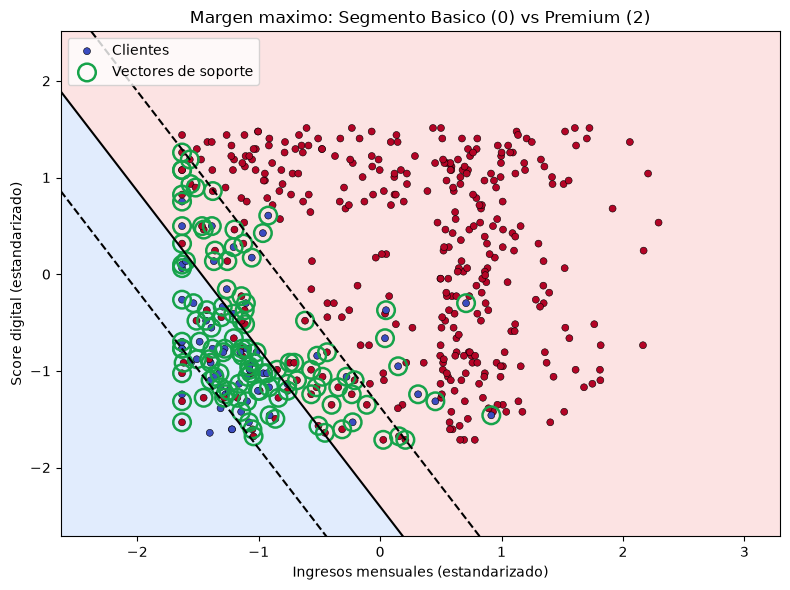

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

x_min, x_max = Xb_tr_s[:, 0].min() - 1, Xb_tr_s[:, 0].max() + 1
y_min, y_max = Xb_tr_s[:, 1].min() - 1, Xb_tr_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = svc_vis.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Frontera de decision (linea solida) y margenes (lineas punteadas, distancia +-1)
ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=["--", "-", "--"], colors="black")
ax.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], alpha=0.15, colors=["#3b82f6", "#ef4444"])

scatter = ax.scatter(Xb_tr_s[:, 0], Xb_tr_s[:, 1], c=yb_tr, cmap="coolwarm",
                      s=25, edgecolors="k", linewidths=0.4, label="Clientes")
ax.scatter(svc_vis.support_vectors_[:, 0], svc_vis.support_vectors_[:, 1],
           s=160, facecolors="none", edgecolors="#16a34a", linewidths=1.8,
           label="Vectores de soporte")

ax.set_xlabel("Ingresos mensuales (estandarizado)")
ax.set_ylabel("Score digital (estandarizado)")
ax.set_title("Margen maximo: Segmento Basico (0) vs Premium (2)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la línea sólida central es la frontera de decisión ($w^Tx+b=0$); las dos líneas punteadas paralelas marcan el borde del margen ($w^Tx+b=\pm 1$). Los puntos rodeados en verde son los vectores de soporte — nótese que caen exactamente sobre las líneas punteadas o dentro de la banda del margen, nunca lejos de ella. La mayoría de los clientes "Básico" (azules) y "Premium" (rojos) están cómodamente lejos de la frontera; son los que se acercan a la zona gris central los que determinan, literalmente, la inclinación y posición de la línea.

---
## 4. El Caso de Margen Duro: Por Qué Falla en Datos Reales 🚧

El ejemplo anterior usó un margen **blando** (soft margin, con $C=1.0$), que permite que algunos puntos violen el margen o incluso caigan del lado equivocado. La formulación original de SVM, sin embargo, es de **margen duro** (*hard margin*): exige que **todos** los puntos de entrenamiento queden correctamente clasificados y fuera del margen, sin excepción. Esto solo es matemáticamente posible si las dos clases son **perfectamente separables** — no puede existir ni un solo par de puntos de clases distintas que se solapen en el espacio de las variables usadas.

En datos reales esto casi nunca ocurre. Para comprobarlo empíricamente, se puede forzar una aproximación al margen duro usando un valor de $C$ extremadamente alto (penaliza casi infinitamente cualquier violación del margen), sobre el mismo subconjunto binario Básico vs. Premium.

In [ ]:
svc_hard = SVC(kernel="linear", C=1e6)  # C muy alto: aproxima el margen duro
svc_hard.fit(Xb_tr_s, yb_tr)

print(f"Margen casi-duro (C=1e6)")
print(f"  Exactitud en entrenamiento: {svc_hard.score(Xb_tr_s, yb_tr):.4f}")
print(f"  Exactitud en prueba: {svc_hard.score(Xb_te_s, yb_te):.4f}")
print(f"  Vectores de soporte: {svc_hard.n_support_}  (total: {svc_hard.support_vectors_.shape[0]})")

print(f"\nMargen blando (C=1.0), para comparar")
print(f"  Exactitud en entrenamiento: {svc_vis.score(Xb_tr_s, yb_tr):.4f}")
print(f"  Exactitud en prueba: {svc_vis.score(Xb_te_s, yb_te):.4f}")
print(f"  Vectores de soporte: {svc_vis.n_support_}  (total: {svc_vis.support_vectors_.shape[0]})")

**Lectura:** el resultado es contundente. Incluso penalizando casi al infinito cualquier violación del margen ($C=10^6$), el modelo **no logra separar perfectamente** las dos clases: la exactitud de entrenamiento es de apenas **89.12%**, es decir, un **10.88%** de los propios datos de entrenamiento quedan mal clasificados o dentro del margen — la prueba directa de que Básico y Premium **no son linealmente separables** en estas dos variables. Esto no es un fallo de optimización: `SVC` en scikit-learn siempre resuelve la formulación de margen *blando*, así que ante datos no separables, un $C$ extremo simplemente produce la mejor aproximación posible a "cero violaciones", sin conseguirlo.

Aún más revelador: la exactitud en **prueba** es idéntica en ambos casos (85.19%), pero el modelo de margen casi-duro usa **menos** vectores de soporte (115 frente a 122) y, al forzar una banda de margen artificialmente angosta entre clases que en realidad se solapan, es más sensible a cómo caen los puntos límite — la exactitud de *entrenamiento* del margen blando (90.25%) es, de hecho, **mayor** que la del margen casi-duro (89.12%), porque permitir algunas violaciones controladas da más flexibilidad para encontrar una frontera razonable en lugar de forzar una casi imposible. Esta es exactamente la motivación del margen blando: en datos reales con solapamiento genuino, insistir en cero errores de entrenamiento no solo es inalcanzable, sino contraproducente.

---
## 5. Formalismo de Margen Blando: Variables de Holgura $\xi_i$ y el Hiperparámetro $C$ ⚖️

El margen blando resuelve el problema anterior introduciendo **variables de holgura** $\xi_i \ge 0$, una por cada punto de entrenamiento, que miden **cuánto** viola ese punto el margen (o si cruza al lado equivocado de la frontera). El problema de optimización queda:

$$\min_{w,\, b,\, \xi} \; \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{N} \xi_i \quad \text{sujeto a} \quad y_i\,(w^Tx_i + b) \ge 1 - \xi_i, \qquad \xi_i \ge 0$$

* Si $\xi_i = 0$: el punto $i$ está correctamente clasificado y fuera del margen — no aporta penalización.
* Si $0 < \xi_i \le 1$: el punto está dentro del margen, pero del lado correcto de la frontera.
* Si $\xi_i > 1$: el punto está del lado **equivocado** de la frontera — mal clasificado.

El término $\frac{1}{2}\|w\|^2$ es inversamente proporcional al ancho del margen (minimizarlo **maximiza** el margen), mientras que $C\sum \xi_i$ penaliza la suma de violaciones. El hiperparámetro $C$ controla el balance entre ambos objetivos:

| Valor de $C$ | Peso de las violaciones | Ancho del margen | Riesgo |
|---|---|---|---|
| **$C$ muy pequeño** (ej. 0.001) | Bajo: se toleran muchas violaciones sin castigo fuerte | Margen **ancho** | **Subajuste** — la frontera prioriza tanto la simplicidad que ignora patrones reales de los datos |
| **$C$ intermedio** | Balance entre margen amplio y pocas violaciones | Moderado | Zona típica del punto óptimo |
| **$C$ muy grande** (ej. $10^6$) | Alto: casi cualquier violación es intolerable | Margen **estrecho** (tiende al margen duro) | **Sobreajuste** — la frontera se retuerce para clasificar bien hasta el último punto de entrenamiento, incluido el ruido |

La Sección 4 ya mostró el extremo de $C$ grande. La Sección 6 mide, con datos reales, todo el espectro intermedio.

---
## 6. Barrido Real de $C$: Encontrando el Punto Óptimo 🔍

Para observar la transición de subajuste a sobreajuste con suficiente margen de maniobra, esta sección vuelve al problema **completo**: las 3 clases (Básico, Estándar, Premium) y las 6 variables numéricas disponibles (`edad`, `ingresos_mensuales`, `gastos_mensuales`, `score_digital`, `llamadas_soporte`, `antiguedad_meses`), no solo el subconjunto binario de 2 variables usado para la visualización. Se entrena un `SVC(kernel="linear")` para 13 valores de $C$, espaciados logarítmicamente entre $10^{-3}$ y $10^{3}$, registrando la exactitud en entrenamiento y en prueba para cada uno.

In [ ]:
features = ["edad", "ingresos_mensuales", "gastos_mensuales",
            "score_digital", "llamadas_soporte", "antiguedad_meses"]
X = df[features].values
y = df["segmento"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

Cs = np.logspace(-3, 3, 13)
train_accs, test_accs = [], []

for C in Cs:
    modelo = SVC(kernel="linear", C=C)
    modelo.fit(X_tr_s, y_tr)
    train_accs.append(modelo.score(X_tr_s, y_tr))
    test_accs.append(modelo.score(X_te_s, y_te))
    print(f"C={C:9.4g}   train={train_accs[-1]:.4f}   test={test_accs[-1]:.4f}")

mejor_idx = int(np.argmax(test_accs))
print(f"\nMejor C segun exactitud de prueba: {Cs[mejor_idx]:.4g}  (exactitud={test_accs[mejor_idx]:.4f})")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(Cs, train_accs, marker="o", label="Entrenamiento")
ax.plot(Cs, test_accs, marker="s", label="Prueba")
ax.axvline(Cs[mejor_idx], color="#16a34a", linestyle="--", alpha=0.7,
           label=f"Mejor C = {Cs[mejor_idx]:.3g}")
ax.set_xscale("log")
ax.set_xlabel("C (escala logaritmica)")
ax.set_ylabel("Exactitud")
ax.set_title("Barrido de C: SVM lineal, 3 clases, 6 variables (clientes_segmentacion_compleja)")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** la curva muestra con claridad la zona de **subajuste**: con $C=0.001$, la exactitud de entrenamiento y de prueba son idénticas y bajas (**58.00%** ambas) — el modelo, con un margen tan amplio que casi ignora las violaciones, termina prediciendo esencialmente siempre la clase mayoritaria (recuérdese que ese 58.0% coincide exactamente con la línea base de "predecir siempre segmento 1" de la Sección 2). La exactitud sube de forma pronunciada entre $C=0.01$ y $C=0.1$ (de 68.00%/69.33% a 70.00%/70.00%), y se **estabiliza** en una meseta entre $C\approx 0.3$ y $C\approx 30$, con el máximo de exactitud de prueba (**71.56%**) en $C=1.0$. Para valores de $C$ aún mayores ($C \ge 100$), la exactitud de entrenamiento se mantiene esencialmente plana (~71.5%) mientras la de prueba cae levemente (70.89%) — un indicio suave de sobreajuste, pero **mucho menos dramático** que lo que se observará con kernels no lineales en el Cuaderno 01: al ser lineal, la capacidad del modelo está limitada por tener solo 6 variables de entrada, así que no hay margen para "memorizar" el ruido de forma tan agresiva como con un kernel curvo. Ese es, precisamente, el problema que introduce el siguiente cuaderno del módulo.

---
## 7. Modelo Final: SVC Lineal Multiclase sobre las 6 Variables 🎯

Con $C=1.0$ identificado como el punto óptimo del barrido, se entrena el modelo final sobre el problema completo de 3 clases y se evalúa con un reporte de clasificación detallado.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

svc_final = SVC(kernel="linear", C=1.0)
svc_final.fit(X_tr_s, y_tr)
pred_final = svc_final.predict(X_te_s)

print(f"Exactitud en prueba: {svc_final.score(X_te_s, y_te):.4f}")
print(f"Vectores de soporte por clase: {svc_final.n_support_}\n")
print("Reporte de clasificacion:")
print(classification_report(y_te, pred_final, digits=4))
print("Matriz de confusion (filas=real, columnas=predicho):")
print(confusion_matrix(y_te, pred_final))

**Lectura:** la exactitud global (**71.56%**) supera con margen razonable la línea base de 58.00%, pero el reporte por clase revela el costo real del desbalance visto en la Sección 2. El segmento 1 (Estándar, la clase mayoritaria) tiene el mejor *recall* (**91.19%**) — el modelo casi nunca se equivoca al identificarlo. El segmento **0** (Básico, solo 29 clientes en prueba) tiene el *recall* más bajo (**37.93%**): la matriz de confusión muestra que 17 de los 29 clientes Básico reales fueron clasificados como Estándar. El segmento 2 (Premium) tiene un *recall* intermedio (**45.62%**), con 81 de 160 confundidos también con Estándar. El patrón es consistente: la clase mayoritaria "atrae" errores de las clases minoritarias, un efecto típico del desbalance de clases que ningún hiperparámetro $C$ por sí solo puede corregir del todo — requeriría técnicas adicionales (ponderación de clases, remuestreo) fuera del alcance de este cuaderno.

---
## 8. Multiclase en scikit-learn: ¿One-vs-Rest o One-vs-One? 🔀

`SVC` fue diseñado originalmente para clasificación **binaria**. Con 3 clases (como `segmento` en este dataset), scikit-learn necesita una estrategia para extender el algoritmo a multiclase. Existen dos enfoques clásicos:

* **One-vs-Rest (OvR):** entrena un clasificador binario por clase, cada uno separando "esa clase" de "todas las demás juntas". Con $K$ clases, requiere $K$ clasificadores.
* **One-vs-One (OvO):** entrena un clasificador binario por **cada par** de clases, ignorando las demás. Con $K$ clases, requiere $K(K-1)/2$ clasificadores.

`SVC` (basado en la librería `libsvm`) usa **internamente One-vs-One**, sin importar el valor del parámetro `decision_function_shape` — ese parámetro solo controla la *forma* de salida de `decision_function` (`'ovo'` u `'ovr'`), no la estrategia de entrenamiento, que siempre es OvO. Con 3 clases, esto implica $3 \times 2 / 2 = 3$ clasificadores binarios: Básico-vs-Estándar, Básico-vs-Premium, y Estándar-vs-Premium; la predicción final se decide por votación entre ellos. *(Nota: la clase relacionada `LinearSVC`, distinta de `SVC(kernel="linear")`, sí implementa One-vs-Rest de forma nativa y usa un solver distinto — más eficiente en datasets grandes, pero con una formulación ligeramente distinta del problema de optimización).*

In [ ]:
n_clases = len(svc_final.classes_)
n_clasificadores_ovo = n_clases * (n_clases - 1) // 2

print("Clases del modelo:", svc_final.classes_)
print(f"Numero de clases: {n_clases}")
print(f"Clasificadores binarios entrenados internamente (One-vs-One): {n_clasificadores_ovo}")

df_scores = svc_final.decision_function(X_te_s[:3])
print(f"\nForma de decision_function para 3 muestras (decision_function_shape='ovr' por defecto): {df_scores.shape}")
print("(una columna por clase, aunque el entrenamiento interno fue One-vs-One)")

**Lectura:** el conteo confirma la teoría: con 3 clases, `SVC` entrenó exactamente **3** clasificadores binarios internos (uno por cada par de segmentos), y el arreglo `n_support_` de la Sección 7 (`[67, 407, 340]`) refleja cuántos vectores de soporte aporta cada clase al conjunto combinado de esos 3 clasificadores. La forma de `decision_function` para 3 muestras es `(3, 3)` — 3 puntuaciones por muestra, una por clase, ya reorganizadas en el formato "ovr" por conveniencia, aunque el cálculo subyacente siga siendo por pares.

---
## 9. Ejercicio Práctico Guiado: ¿Realmente Hace Falta Escalar? ✍️

**Contexto:** todo este cuaderno insistió en estandarizar las variables antes de entrenar, con el argumento de que SVM —como KNN— es sensible a la escala porque se basa en distancias entre puntos. Pero, ¿qué tan grave es el efecto en la práctica? Este ejercicio lo mide directamente.

**Tu misión:**
1. Entrena un `SVC(kernel="linear", C=1.0, max_iter=5000)` sobre `X_tr`, `y_tr` **sin escalar** (usa los arreglos originales `X_tr`/`X_te` de la Sección 6, no las versiones `_s`). Usa `warnings.catch_warnings(record=True)` con `warnings.simplefilter("always")` alrededor del `.fit()` para capturar cualquier advertencia del solver.
2. Imprime las advertencias capturadas (si las hay) y calcula la exactitud en entrenamiento y en prueba de este modelo sin escalar.
3. Compara esa exactitud con la del modelo escalado de la Sección 7 (`svc_final`, exactitud de prueba 0.7156) y con la línea base de 0.58 de la Sección 2.
4. Interpreta el resultado en un comentario: ¿escalar fue realmente necesario en este caso, o solo una buena práctica preventiva?

In [ ]:
### TU CODIGO AQUI ###
import warnings

# 1. Entrena sin escalar, capturando advertencias del solver
modelo_sin_escalar = None  # SVC(kernel="linear", C=1.0, max_iter=5000)
advertencias = None

# 2. Exactitud en entrenamiento y prueba (datos SIN escalar)
acc_train_sin_escalar = None
acc_test_sin_escalar = None

# 3. Compara contra el modelo escalado (0.7156) y la linea base (0.58)

# 4. Escribe tu interpretacion como comentario aqui

<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
import warnings

with warnings.catch_warnings(record=True) as advertencias:
    warnings.simplefilter("always")
    modelo_sin_escalar = SVC(kernel="linear", C=1.0, max_iter=5000)
    modelo_sin_escalar.fit(X_tr, y_tr)  # X_tr SIN escalar

for w in advertencias:
    print("Advertencia:", str(w.message))

acc_train_sin_escalar = modelo_sin_escalar.score(X_tr, y_tr)
acc_test_sin_escalar = modelo_sin_escalar.score(X_te, y_te)

print(f"\nSin escalar -> train: {acc_train_sin_escalar:.4f}  test: {acc_test_sin_escalar:.4f}")
print(f"Escalado (Seccion 7) -> train: 0.7133  test: 0.7156")
print(f"Linea base (Seccion 2) -> 0.5800")
```

Resultado real:

```
Advertencia: Solver terminated early (max_iter=5000). Consider pre-processing your data with
StandardScaler or MinMaxScaler.

Sin escalar -> train: 0.3667  test: 0.3489
Escalado (Seccion 7)  -> train: 0.7133  test: 0.7156
Linea base (Seccion 2) -> 0.5800
```

**Interpretación:** el efecto es dramático, no cosmético. El solver ni siquiera logra converger en 5000 iteraciones sobre los datos sin escalar —scikit-learn lo advierte explícitamente y sugiere `StandardScaler`— y el modelo resultante (**36.67%** de exactitud en entrenamiento, **34.89%** en prueba) queda **muy por debajo incluso de la línea base ingenua** de predecir siempre la clase mayoritaria (58.00%). La causa es la enorme disparidad de escalas entre variables: `ingresos_mensuales` toma valores del orden de millones, mientras que `score_digital` va de 0 a 100 y `llamadas_soporte` rara vez supera 10 — el optimizador, que busca minimizar $\frac{1}{2}\|w\|^2$, queda dominado casi por completo por la variable de mayor magnitud numérica, distorsionando por completo la geometría del problema. La respuesta a la pregunta del ejercicio es clara: para este dataset, escalar no fue una buena práctica opcional — fue la diferencia entre un modelo utilizable (71.56%) y uno que ni siquiera converge a una solución razonable.

</details>

---
## 10. Resumen Ejecutivo 🎓

Este cuaderno introdujo el principio fundacional de las Máquinas de Soporte Vectorial: entre todas las fronteras que separan dos clases, elegir la que **maximiza el margen** hacia los puntos más cercanos (los **vectores de soporte**). Los hallazgos centrales, todos medidos sobre `clientes_segmentacion_compleja.csv`:

- **El margen duro es frágil ante datos reales:** incluso forzando $C=10^6$, el subconjunto Básico-vs-Premium no se pudo separar perfectamente (89.12% de exactitud de entrenamiento, no 100%) — la evidencia directa de que exigir cero errores de entrenamiento es, en datos con solapamiento genuino, no solo inalcanzable sino contraproducente.
- **El margen blando, formalizado con variables de holgura $\xi_i$ y el hiperparámetro $C$, resuelve ese problema** permitiendo violaciones controladas del margen a cambio de una frontera más estable y generalizable.
- **El barrido real de $C$** mostró la transición completa: subajuste severo en $C=0.001$ (58.00%, igual a la línea base), una meseta óptima entre $C\approx 0.3$ y $C\approx 30$ (máximo de 71.56% en $C=1.0$), y una leve señal de sobreajuste en $C$ muy grandes — mucho más contenida que la que producirán los kernels no lineales del siguiente cuaderno, porque la capacidad de un modelo lineal está acotada por el número de variables de entrada.
- **El desbalance de clases limita el techo de exactitud por clase:** el segmento minoritario (Básico, 6.4% de los datos) tuvo el *recall* más bajo (37.93%), un recordatorio de que ni el mejor $C$ corrige por sí solo un desbalance estructural en los datos.
- **`SVC` resuelve el problema multiclase con One-vs-One internamente** (3 clasificadores binarios para 3 clases), independientemente de la forma de salida solicitada.
- **Escalar no es opcional:** sin `StandardScaler`, el solver ni siquiera converge y la exactitud cae por debajo de la línea base ingenua (34.89% vs. 58.00%).

**Hacia adelante en el Módulo 06:** este cuaderno se limitó a fronteras **rectas**. El Cuaderno **01 — El Truco del Kernel: Fronteras No Lineales y SVR** — muestra qué ocurre cuando ni siquiera el mejor $C$ basta porque los datos no son separables por una línea recta, e introduce los kernels RBF y polinomial, además de la regresión SVR. Los Cuadernos **02 (Redes Neuronales)** y **03 (Retropropagación)** cambian de familia de algoritmo por completo, explorando cómo una red de unidades simples puede aprender fronteras arbitrariamente complejas sin necesidad de elegir un kernel a mano. El Cuaderno **04 (Comparativa)** cierra el módulo evaluando cuándo conviene SVM y cuándo conviene una red neuronal, con evidencia empírica sobre los mismos datos.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | SVM y Redes Neuronales</i>
  </p>
</div>